In [2]:
import numpy as np
from qiskit.circuit.library import UnitaryGate

U = np.array([
    [0,  1],
    [1, 0]
], dtype=complex)

compuerta_U = UnitaryGate(U, label="U")
compuerta_CU = compuerta_U.control(1)

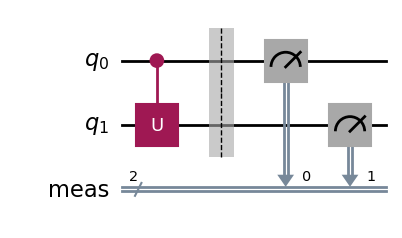

In [8]:
from qiskit import QuantumCircuit

circuito = QuantumCircuit(2)
circuito.x(0)
circuito.x(1)
circuito.append(compuerta_CU,[0, 1])
circuito.measure_all()
circuito.draw("mpl")

In [7]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

simulador = StatevectorSampler()

trabajo = simulador.run(
    [circuito],
    shots=10000
)

resultado = trabajo.result()
conteos = resultado[0].data.meas.get_counts()

plot_histogram(conteos)